# Stage 1

## **Libraries**

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
from pathlib import Path
import torch.nn.functional as F
import torch.nn as nn
import torch
import albumentations as A
from torch.amp import autocast, GradScaler
from albumentations import (
    Compose, Rotate, HorizontalFlip, VerticalFlip,
    GaussNoise, GaussianBlur, RandomBrightnessContrast,
    ElasticTransform, GridDistortion, OpticalDistortion,
    RandomRain, RandomFog, RandomSunFlare,
    RandomShadow, CoarseDropout, CoarseDropout,
    Normalize, Resize
)
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import warnings
import random
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed()
warnings.filterwarnings("ignore")

In [5]:
CONFIG = {
    "Height": 256,
    "Width": 1600,
    "n_classes": 4,
    "val_split": 0.2,
    "batch_size": 16,
    "num_workers": 2,
    "epochs": 300,
    "lr": 1e-2,
    "Seed": 42,
    "THRESHOLD": 0.5,
    "n_channels": 3
}

DATA_DIR = Path("/Users/thachphung/Documents/Graduation Project/Dataset")
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR = DATA_DIR / "test_images"
TRAIN_CSV = DATA_DIR / "train.csv"
WORK_DIR  = Path("/content/drive/MyDrive/Graduation Project/checkpoint")

## Data

In [6]:
df = pd.read_csv(TRAIN_CSV)
print(len(df))
df.info()

7095
<class 'pandas.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ImageId        7095 non-null   str  
 1   ClassId        7095 non-null   int64
 2   EncodedPixels  7095 non-null   str  
dtypes: int64(1), str(2)
memory usage: 166.4 KB


In [7]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


The number of all images is  12568
The number of all images with defect  6666
The number of all images without defect  5902


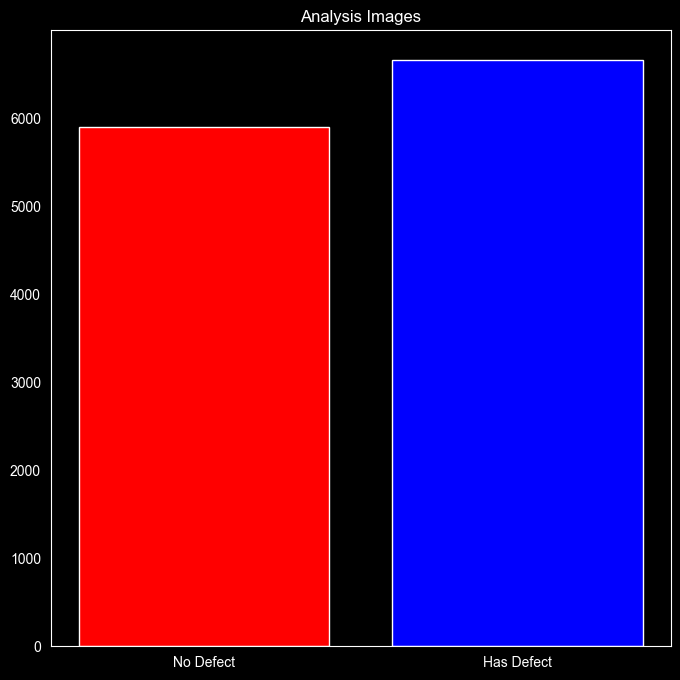

In [8]:
# Get all images from training Image
all_images = os.listdir(TRAIN_DIR)
all_images = [img for img in all_images if img.endswith((".jpg", ".png"))]

# Image id from csv
defect_images = df["ImageId"].unique().tolist()

# Image no defect
no_defect_images = set(all_images) - set(defect_images)

print("The number of all images is ", len(all_images))
print("The number of all images with defect ", len(defect_images))
print("The number of all images without defect ", len(no_defect_images))

# Bar plot
plt.figure(figsize=(8, 8))
plt.bar(["No Defect", "Has Defect"], [len(no_defect_images), len(defect_images)], color=["red", "blue"])
plt.title("Analysis Images")
plt.grid(False)
plt.show()

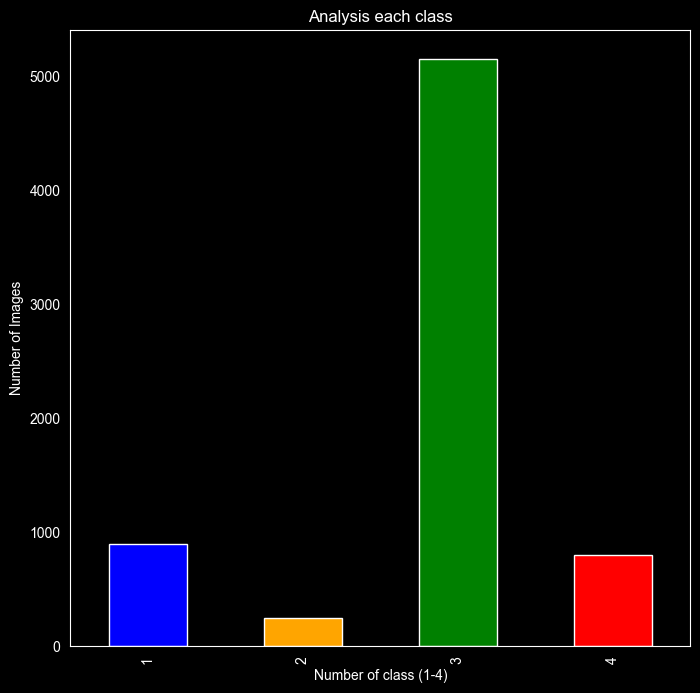

In [9]:
class_counts = (df[df["EncodedPixels"].notnull()].groupby("ClassId")["ImageId"].nunique())

# Total samples
total_images = df["ImageId"].nunique()
plt.figure(figsize=(8,8))
class_counts.plot(kind="bar", color=["blue","orange","green","red"])
plt.title("Analysis each class")
plt.ylabel("Number of Images")
plt.xlabel("Number of class (1-4)")
plt.grid(False)
plt.show()

### Preprocessing

In [9]:
class RLEprocessor:
    """RLE encoding and decoding"""

    @staticmethod
    def rle_decoder(rle_str, shape=(CONFIG['Height'], CONFIG['Width'])) -> np.ndarray:
        rle_list = rle_str.split()  # convert to list
        assert isinstance(rle_list, list)  # if is list, be passed
        start, length = [np.asarray(x, dtype=int) for x in (rle_list[0::2], rle_list[1::2])]
        # start = [rle_list[x] - 1 for x in range(0, len(rle_list), 2)]
        # length = [rle_list[x] for x in range(1, len(rle_list), 2)]
        start -= 1
        ends = start + length
        image = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for start, end in zip(start, ends):
            image[start:end] = 1
        return image.reshape(shape, order='F')

    @staticmethod
    def build_masks(df: pd.DataFrame, image_id: str) -> np.ndarray:
        mask = np.zeros((CONFIG["Height"], CONFIG['Width'], CONFIG['n_classes']), dtype=np.uint8)

        for i in range(1, 5):
            rle = df.loc[
                (df["ImageId"] == image_id) & (df['ClassId']== i), "EncodedPixels"
            ]
            if len(rle) > 0:
                rle = rle.values[0]
                if pd.notna(rle):
                    mask[:,:, i-1] = RLEprocessor.rle_decoder(rle)
        return mask

    @staticmethod
    def rle_encoder(mask):
        pixels = mask.T.flatten(order='F')
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Use 0 to covert tuple to nparray
        runs[1::2] -= runs[::2]
        return ' '.join(str(x) for x in runs)

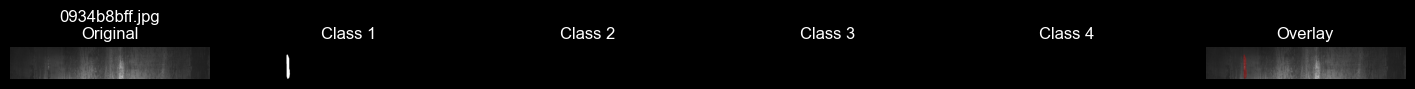

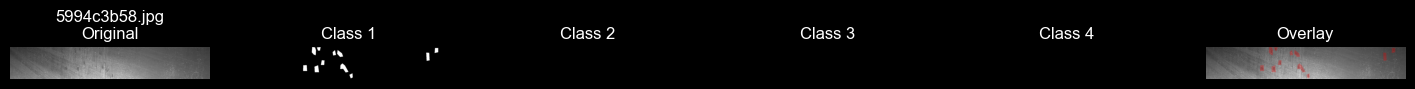

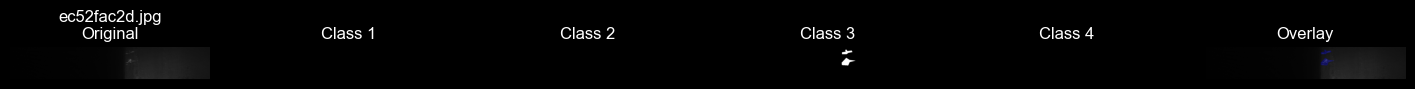

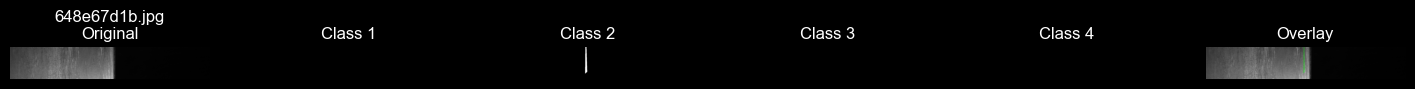

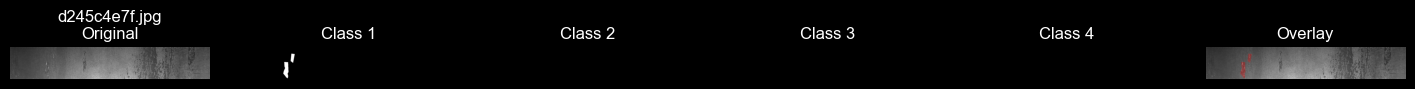

In [11]:
sample_images = df["ImageId"].drop_duplicates().sample(5, random_state=42).tolist()

for image_id in sample_images:
    img_path = TRAIN_DIR / image_id
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = RLEprocessor.build_masks(df, image_id)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1)
    plt.imshow(img)
    plt.title(f"{image_id}\nOriginal")
    plt.axis("off")

    # Sınıf maskeleri
    for i in range(4):
        plt.subplot(1,6,i+2)
        plt.imshow(masks[..., i], cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")

    # Overlay
    overlay = img.copy()
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]  # R, G, B, Sarı
    for i in range(4):
        mask = masks[..., i].astype(bool)
        overlay[mask] = (0.7*overlay[mask] + 0.3*np.array(colors[i])).astype(np.uint8)

    plt.subplot(1,6,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

### Augmentation

In [52]:
from albumentations.pytorch import ToTensorV2
import albumentations as A
train_transform = A.Compose([
                # Geometric transforms (for steel defect pattern variation)
                HorizontalFlip(p=0.6),
                VerticalFlip(p=0.4),
                Rotate(limit=20, p=0.5),
                ElasticTransform(alpha=50, sigma=8, p=0.4),
                GridDistortion(num_steps=5, distortion_limit=0.4, p=0.3),
                OpticalDistortion(distortion_limit=0.3, shift_limit=0.3, p=0.3),

                # Color/Intensity transforms (simulate different lighting, camera settings)
                RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.5),
                GaussNoise(var_limit=(15, 60), p=0.4),
                GaussianBlur(blur_limit=5, p=0.3),
                RandomShadow(p=0.2),
                RandomFog(p=0.15),

                # Cutout strategy (để checkpoint học từ partial defects)
                CoarseDropout(
                    max_holes=8,
                    max_height=30,
                    max_width=30,
                    min_holes=1,
                    min_height=10,
                    min_width=10,
                    p=0.3
                ),

                # Normalization
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
val_transform = A.Compose([
                HorizontalFlip(p=0.5),
                VerticalFlip(p=0.3),
                Rotate(limit=10, p=0.3),
                RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
                GaussNoise(p=0.2),
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], keypoint_params=None)

NameError: name 'HorizontalFlip' is not defined

### Build data

In [11]:
class SteverstalDataset(Dataset):
    """PyTorch Dataset for Severstal"""

    def __init__(self, image_ids, df: pd.DataFrame, image_dir, transform=None, load_rgb=True):
        self.df = df
        self.image_dir = Path(image_dir)
        self.image_ids= list(image_ids)
        self.transform = transform
        self.load_rgb = load_rgb

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {image_id}")
        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)  # (H,W,3)
        return img


    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = self._read_image(image_id)
        mask = RLEprocessor.build_masks(self.df, image_id)

        if self.transform:
            output = self.transform(image=image, mask=mask)
            image, mask = output['image'], output['mask'].permute(2, 0, 1) # (C, H, W)
        else:
            image = torch.from_numpy(image.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask.transpose(2,0,1)).float()

        meta = {"image_id": image_id}
        return {
            'image': image,   # (3, H, W)
            'mask': mask,     # (4, H, W)
            'image_id': image_id
        }


# --- Collate function ---
def collate_fn(batch):
    images, masks, metas = zip(*batch)
    images = torch.stack(images)
    masks = torch.stack(masks)
    return images, masks, metas

### Dataset , Dataloader

In [12]:
train_ids, valid_ids = train_test_split(
    df["ImageId"].unique(),
    test_size=0.4,
    random_state=CONFIG["Seed"])
valid_ids, test_ids = train_test_split(valid_ids, test_size=0.5, random_state=CONFIG['Seed'])

In [13]:
train_ds = SteverstalDataset(train_ids, df, TRAIN_DIR, transform=train_transform)
val_ds = SteverstalDataset(valid_ids, df, TRAIN_DIR, transform=val_transform)
test_ds = SteverstalDataset(test_ids, df, TRAIN_DIR, transform=val_transform)

In [14]:
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

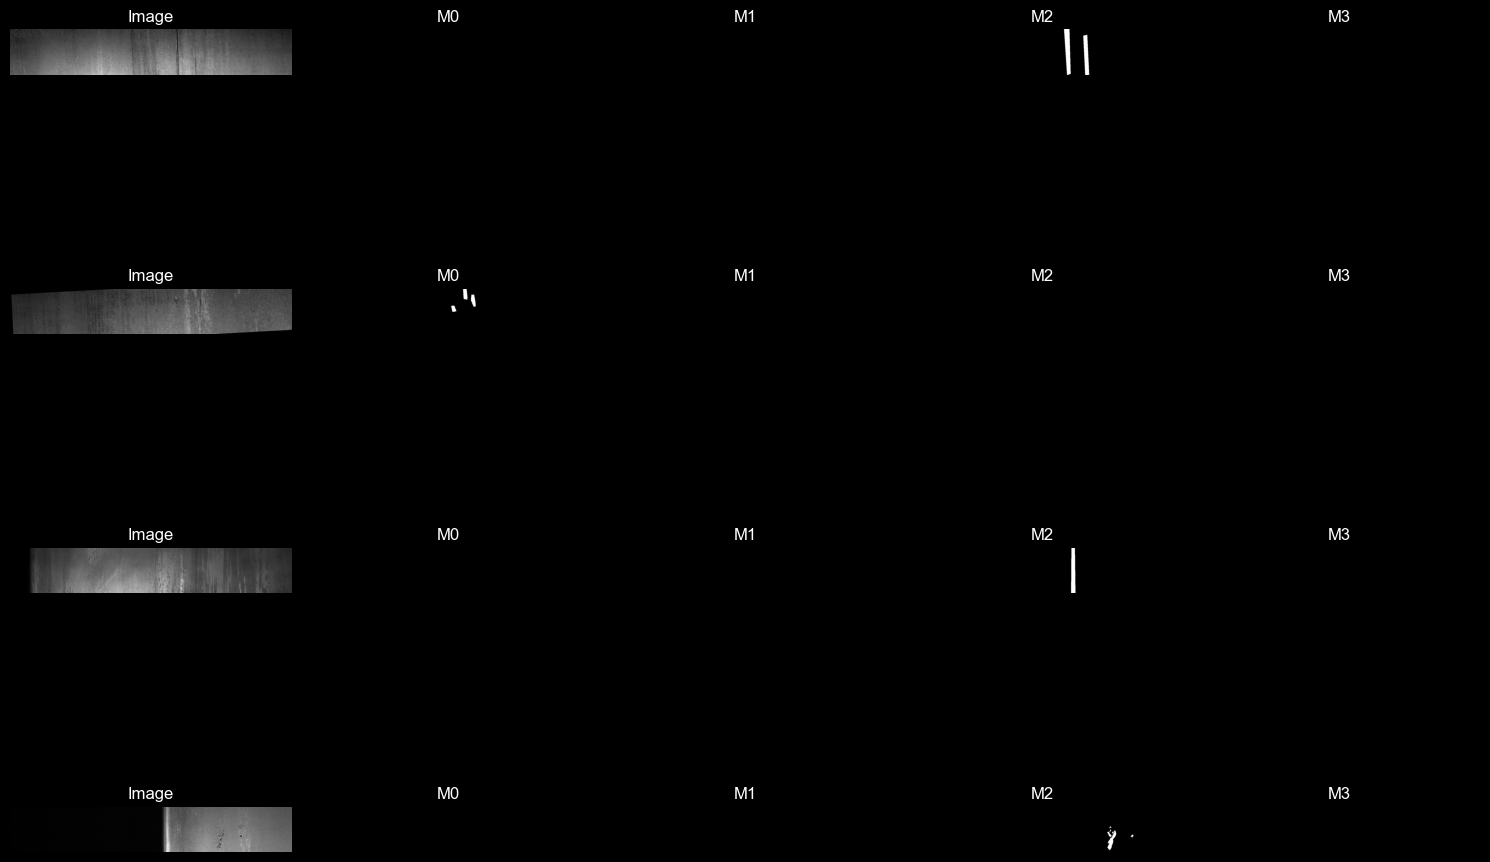

In [19]:
batch = next(iter(train_loader))
images = batch['image']
masks = batch['mask']
B = images.shape[0]  # batch size
num_show = min(4, B)  # hiển thị tối đa 4 sample

plt.figure(figsize=(15, 3 * num_show))

for i in range(num_show):
    img = images[i].cpu().numpy()[0]   # (H, W)
    mask = masks[i].cpu().numpy()      # (4, H, W)
    #print(mask[i])

    # unnormalize nếu cần
    img = (img * 0.5) + 0.5

    # ===== Image =====
    plt.subplot(num_show, 5, i*5 + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    # ===== 4 Masks =====
    for j in range(4):
        plt.subplot(num_show, 5, i*5 + 2 + j)
        plt.imshow(mask[j,:,:], cmap='gray')
        plt.title(f"M{j}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## Model

In [26]:
class AttentionBlock(nn.Module):
    """Attention Gate Block"""
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class DoubleConv(nn.Module):
    """Double Convolution Block"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super(DoubleConv, self).__init__()
        if mid_channels is None:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [35]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

In [57]:
class Resnet18_Unet(nn.Module):
    """
    Attention U-Net for Steel Defect Segmentation
    Input: (B, 3, 256, 1600)
    Output: (B, 4, 256, 1600)

    Architecture designed for ~32M parameters
    """
    def __init__(self, in_channels=3, out_channels=4, init_features=32, pretrained=True):
        super(Resnet18_Unet, self).__init__()

        features = [init_features*2 ,init_features*2, init_features*4, init_features*8, init_features*16]
        # features = [32, 64, 128, 256, 512] if init_feature = 64 [64, 128, 256, 512, 1024]

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        # Encoder
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        del base.fc, base.avgpool
        base.conv1 = nn.Conv2d( in_channels, 64, kernel_size=7,stride=1, padding=3, bias=False)
        self.enc1 = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.enc2 = nn.Sequential(base.maxpool, base.layer1)
        self.enc3 = base.layer2
        self.enc4 = base.layer3
        self.enc5 = base.layer4

        # Bottleneck
        self.bottleneck = DoubleConv(features[4], features[4]*2)

        # Decoder with Attention
        self.upconv5 = nn.ConvTranspose2d(features[4]*2, features[4], kernel_size=2, stride=2)
        self.attn5 = AttentionBlock(F_g=features[4], F_l=features[4], F_int=features[4]//2)
        self.dec5 = DoubleConv(features[4]*2, features[4])

        self.upconv4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.attn4 = AttentionBlock(F_g=features[3], F_l=features[3], F_int=features[3]//2)
        self.dec4 = DoubleConv(features[3]*2, features[3])

        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.attn3 = AttentionBlock(F_g=features[2], F_l=features[2], F_int=features[2]//2)
        self.dec3 = DoubleConv(features[2]*2, features[2])

        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.attn2 = AttentionBlock(F_g=features[1], F_l=features[1], F_int=features[1]//2)
        self.dec2 = DoubleConv(features[1]*2, features[1])

        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.attn1 = AttentionBlock(F_g=features[0], F_l=features[0], F_int=features[0]//2)
        self.dec1 = DoubleConv(features[0]*2, features[0])

        # Final output
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(enc1)
        enc3 = self.enc3(enc2)
        enc4 = self.enc4(enc3)
        enc5 = self.enc5(enc4)

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc5))

        # Decoder
        dec5 = self.upconv5(bottleneck)
        attn5 = self.attn5(g=dec5, x=enc5)
        dec5 = self.dec5(torch.cat([attn5, dec5], dim=1))

        dec4 = self.upconv4(dec5)
        attn4 = self.attn4(g=dec4, x=enc4)
        dec4 = self.dec4(torch.cat([attn4, dec4], dim=1))

        dec3 = self.upconv3(dec4)
        attn3 = self.attn3(g=dec3, x=enc3)
        dec3 = self.dec3(torch.cat([attn3, dec3], dim=1))

        dec2 = self.upconv2(dec3)
        attn2 = self.attn2(g=dec2, x=enc2)
        dec2 = self.dec2(torch.cat([attn2, dec2], dim=1))

        dec1 = self.upconv1(dec2)
        attn1 = self.attn1(g=dec1, x=enc1)
        dec1 = self.dec1(torch.cat([attn1, dec1], dim=1))

        # Output
        output = self.final_conv(dec1)
        return output

In [58]:
model = Resnet18_Unet(in_channels=3, out_channels=4)
from torchinfo import summary
summary(model, input_size=(8, 3, 256, 1600))

Layer (type:depth-idx)                   Output Shape              Param #
Resnet18_Unet                            [8, 4, 256, 1600]         --
├─Sequential: 1-1                        [8, 64, 256, 1600]        --
│    └─Conv2d: 2-1                       [8, 64, 256, 1600]        9,408
│    └─BatchNorm2d: 2-2                  [8, 64, 256, 1600]        128
│    └─ReLU: 2-3                         [8, 64, 256, 1600]        --
├─Sequential: 1-2                        [8, 64, 128, 800]         --
│    └─MaxPool2d: 2-4                    [8, 64, 128, 800]         --
│    └─Sequential: 2-5                   [8, 64, 128, 800]         --
│    │    └─BasicBlock: 3-1              [8, 64, 128, 800]         73,984
│    │    └─BasicBlock: 3-2              [8, 64, 128, 800]         73,984
├─Sequential: 1-3                        [8, 128, 64, 400]         --
│    └─BasicBlock: 2-6                   [8, 128, 64, 400]         --
│    │    └─Conv2d: 3-3                  [8, 128, 64, 400]         73,728

## Metrics

In [ ]:
import segmentation_models_pytorch as smp

class BCEDiceLoss(torch.nn.Module):
    def __init__(self, bce_weight=0.3, dice_weight=0.7, class_weights=None):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = torch.nn.BCEWithLogitsLoss(weight=class_weights)  # weight áp dụng cho positive
        self.dice = smp.losses.DiceLoss(mode='multilabel',
                                       from_logits=True,
                                       smooth=1.0)

    def forward(self, pred, target):
        """
        pred:   (B, 4, H, W) - logits
        target: (B, 4, H, W) - float 0/1
        """
        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0, class_weights=None):
        super().__init__()

        self.smooth = smooth
        self.class_weights = class_weights

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        intersection = (pred * target).sum(dim=(2,3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        loss = 1 - dice

        if self.class_weights is not None:
            weights = torch.tensor(
                self.class_weights,
                device=pred.device
            ).view(1, -1)

            loss = loss * weights

        return loss.mean()


class WeightedDiceLoss(nn.Module):
    """Weighted Dice Loss - xử lý class imbalance"""
    def __init__(self, smooth=1.0, class_weights=None):
        super(WeightedDiceLoss, self).__init__()
        self.smooth = smooth
        self.class_weights = class_weights  # [w0, w1, w2, w3]

    def forward(self, pred, target):
        pred = F.softmax(pred, dim=1)

        dice_loss = 0.0
        num_classes = pred.shape[1]

        for c in range(num_classes):
            pred_c = pred[:, c, :, :]
            target_c = (target == c).float()

            intersection = (pred_c * target_c).sum()
            union = pred_c.sum() + target_c.sum()

            dice_c = (2 * intersection + self.smooth) / (union + self.smooth)

            weight = self.class_weights[c] if self.class_weights is not None else 1.0
            dice_loss += weight * (1 - dice_c)

        return dice_loss


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, pos_weight=None):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

        self.pos_weight = pos_weight

    def forward(self, pred, target):

        bce = F.binary_cross_entropy_with_logits(
            pred,
            target,
            reduction='none',
            pos_weight=self.pos_weight
        )

        pt = torch.exp(-bce)

        focal = self.alpha * (1 - pt) ** self.gamma * bce

        return focal.mean()


class DiceFocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.5,
        dice_weights=None,
        focal_weight=None
    ):
        super().__init__()

        self.alpha = alpha

        self.dice = DiceLoss(
            class_weights=dice_weights
        )

        self.focal = FocalLoss(
            pos_weight=focal_weight
        )

    def forward(self, pred, target):

        dice_loss = self.dice(pred, target)

        focal_loss = self.focal(pred, target)

        return (
            self.alpha * dice_loss
            + (1 - self.alpha) * focal_loss
        )

@torch.no_grad()
def dice_coefficient(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((2,3)); den = preds.sum((2,3))+targets.sum((2,3))
    dice = (2*inter+eps)/(den+eps)
    return dice.mean()

@torch.no_grad()
def dice_per_class(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((0,2,3)); den = preds.sum((0,2,3))+targets.sum((0,2,3))
    return ((2*inter+eps)/(den+eps)).cpu().tolist()



## Training

In [31]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.to(device)
    model.train()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Train", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].float().to(device)
        optimizer.zero_grad()
        with autocast("cuda"):

            outputs = model(imgs)

            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(outputs, masks).item() * bs
    return {"loss": run_loss / n, "dice": run_dice / n}

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):

    model.to(device)
    model.eval()
    run_loss, run_dice, n = 0.0, 0.0, 0

    for batch in tqdm(loader, desc="Valid", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].float().to(device)
        with autocast("cuda"):
            out = model(imgs)
            loss = criterion(out, masks)
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {
        "loss": run_loss / n,
        "dice": run_dice / n
    }


In [94]:
class EarlyStopping:
    def __init__(self, patience=5, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.stop = False

    def __call__(self, score):
        if self.best is None:
            self.best = score; self.count = 0
        else:
            improve = (score > self.best) if self.mode=="max" else (score < self.best)
            if improve:
                self.best = score; self.count = 0
            else:
                self.count += 1
                if self.count >= self.patience:
                    self.stop = True

In [98]:
def fit(model, train_loader, val_loader, optimizer, scheduler, criterion, scaler, device,
        num_epochs, early_stopping_patience=5, save_path="best_model.pth"):
    early_stopping = EarlyStopping(patience=early_stopping_patience, mode="max")
    best_dice = -1.0

    history = {"train": [], "valid": []}

    for epoch in range(1, num_epochs+1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        all_val_dice = []
        for batch in val_loader:
            imgs = batch["image"].to(device)
            masks = batch["mask"].float().to(device)
            with autocast("cuda"):
              out = model(imgs)
            all_val_dice.append(dice_per_class(out, masks))
        val_metrics["per_class_dice"] = np.mean(all_val_dice, axis=0).tolist()

        scheduler.step(val_metrics["dice"])

        print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        print(f"Valid Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}")

        history["train"].append({**train_metrics, "lr": optimizer.param_groups[0]["lr"]})
        history["valid"].append(val_metrics)

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"Best checkpoint saved at epoch {epoch} (dice={best_dice:.4f})")

        early_stopping(val_metrics["dice"])
        if early_stopping.stop:
            print("⏹Early stopping triggered.")
            break

    print(f"Training finished. Best Dice = {best_dice:.4f}")
    return history


In [97]:
def plot_history(history, out_dir=WORK_DIR, show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure()
    plt.plot(tr_d, label="Train")
    plt.plot(va_d, label="Valid")
    plt.title("Dice Score")
    plt.legend()
    plt.savefig(out_dir / "dice_curve.png")
    if show: plt.show()
    plt.close()

    # Loss
    plt.figure()
    plt.plot(tr_l, label="Train")
    plt.plot(va_l, label="Valid")
    plt.title("Loss")
    plt.legend()
    plt.savefig(out_dir / "loss_curve.png")
    if show: plt.show()
    plt.close()

    # Learning Rate
    plt.figure()
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.legend()
    plt.savefig(out_dir / "lr_curve.png")
    if show: plt.show()
    plt.close()

import matplotlib.pyplot as plt
import numpy as np
import torch

# 1) Draw the Training Process Graphs
def plot_training_curves(history, out_dir=WORK_DIR):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"dice_curve.png")
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"loss_curve.png")
    plt.show()

    # LR
    plt.figure(figsize=(6,4))
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    plt.savefig(out_dir/"lr_curve.png")
    plt.show()

#2) Dice Scores by Class
@torch.no_grad()
def plot_per_class_dice(model, loader, device, class_names=None):
    model.eval()
    dices = []
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        dices.append(dice_per_class(logits, masks))

    dices = np.array(dices).mean(0)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(dices))]

    plt.figure(figsize=(6,4))
    plt.bar(class_names, dices, color=["blue","orange","green","red"])
    plt.title("Per-Class Dice Scores")
    plt.ylabel("Dice")
    plt.ylim(0,1)
    plt.grid(True, axis="y")
    plt.show()


#3) Example Prediction Visualization
@torch.no_grad()
def visualize_predictions(model, dataset, device, k=3, thr=CFG["THRESHOLD"]):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(k,len(dataset)), replace=False)
    for i in idxs:
        img, mask, meta = dataset[i]
        x = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
        pred_bin = (pred > thr).astype(np.uint8)

        img_np  = img.permute(1,2,0).numpy()
        mask_np = mask.permute(1,2,0).numpy()

        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8))
        axs[0].set_title(meta["image_id"]); axs[0].axis("off")

        axs[1].imshow(mask_np.max(-1), cmap="gray")
        axs[1].set_title("Ground Truth"); axs[1].axis("off")

        axs[2].imshow(pred_bin.max(-1), cmap="gray")
        axs[2].set_title("Prediction"); axs[2].axis("off")
        plt.show()

NameError: name 'WORK_DIR' is not defined

In [50]:
model = Resnet18_Unet(in_channels=CONFIG["n_channels"], out_channels=CONFIG["n_classes"])
criterion = BCEDiceLoss(bce_weight=0.3, dice_weight=0.7, class_weights=)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
scaler = GradScaler("cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not found, running on CPU.")


# Start the training and capture the history
history = fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device,
              num_epochs=CONFIG["epochs"], early_stopping_patience=12, save_path="best_model.pth")

# Record the final epoch at the end of the training.
torch.save(model.state_dict(), "last_model.pth")

# --- Post-training analysis and visualization ---

# 1) Training process graphs (loss, dice, lr)
plot_history(history, show=True)        # Both save and display on screen
plot_training_curves(history)           # A more stylish look with subplot

#2) Dice scores by class (based on validation set)
plot_per_class_dice(model, val_loader, device)

# 3) Example prediction visuals (GT vs Pred overlay)
visualize_predictions(model, val_ds, device, k=3)

# The way to reload the best checkpoint
best_path = "best_model.pth"

# Stage 2

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from tqdm import tqdm

CLS_CROP_SIZE = (384, 384)  # (H, W)
CLS_OUT_DIR = WORK_DIR / "cls_stage2"
CLS_CROP_DIR = CLS_OUT_DIR / "crops"
CLS_OUT_DIR.mkdir(parents=True, exist_ok=True)
CLS_CROP_DIR.mkdir(parents=True, exist_ok=True)

@torch.no_grad()
def predict_masks_for_batch(model, imgs, thr=0.5):
    """Return binary masks [B,C,H,W] on CPU (uint8)."""
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    masks = (probs > thr).to(torch.uint8)
    return masks.cpu()

def _find_bboxes_from_binary_mask(mask2d, min_area=50):
    """mask2d: uint8 {0,1}.
    return list of (x1,y1,x2,y2) in pixel coords.
    """
    m = (mask2d * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if w * h < min_area:
            continue
        bboxes.append((x, y, x + w, y + h))
    return bboxes

def _clip_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, x1))
    y1 = max(0, min(H - 1, y1))
    x2 = max(1, min(W, x2))
    y2 = max(1, min(H, y2))
    return x1, y1, x2, y2

def build_stage2_crops_from_predictions(
    model,
    test_loader,
    test_image_dir: Path,
    out_csv_path: Path,
    thr=0.5,
    min_component_area=80,
    label_min_pixels=30,
    bbox_margin=12,
    max_crops_per_image=12,
):
    """Tạo crop dataset + pseudo multi-label từ mask dự đoán.

    Ghi file CSV gồm:
      crop_path, image_id, x1,y1,x2,y2, y1..y4
    """
    model.eval()
    rows = []

    for imgs, image_ids in tqdm(test_loader, desc="Stage2 crops", leave=False):
        imgs = imgs.to(device)
        masks_b = predict_masks_for_batch(model, imgs, thr=thr)  # [B,C,H,W] uint8 cpu

        for bi, image_id in enumerate(image_ids):
            # đọc ảnh gốc (grayscale -> 3ch) để crop
            img_path = test_image_dir / image_id
            img0 = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img0 is None:
                continue
            img0 = np.repeat(img0[..., None], 3, axis=2)  # HxWx3

            # resize ảnh gốc về đúng size đang dùng trong segmentation (để bbox khớp mask)
            Hm, Wm = masks_b.shape[-2], masks_b.shape[-1]
            if img0.shape[0] != Hm or img0.shape[1] != Wm:
                img0 = cv2.resize(img0, (Wm, Hm), interpolation=cv2.INTER_LINEAR)

            # gom bbox từ mọi class
            bboxes = []
            for c in range(masks_b.shape[1]):
                m2d = masks_b[bi, c].numpy()
                bboxes += _find_bboxes_from_binary_mask(m2d, min_area=min_component_area)

            # nếu không có bbox nào: bỏ qua ảnh này
            if len(bboxes) == 0:
                continue

            # sort bbox theo diện tích giảm dần, giới hạn số crop/ảnh
            bboxes = sorted(bboxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]), reverse=True)[:max_crops_per_image]

            H, W = img0.shape[:2]

            for k, (x1, y1, x2, y2) in enumerate(bboxes):
                # nới bbox
                x1 -= bbox_margin; y1 -= bbox_margin
                x2 += bbox_margin; y2 += bbox_margin
                x1, y1, x2, y2 = _clip_bbox(x1, y1, x2, y2, W=W, H=H)

                crop = img0[y1:y2, x1:x2]
                if crop.size == 0:
                    continue

                # pseudo multi-label: lớp nào có đủ pixel trong bbox thì bật 1
                ys = []
                for c in range(masks_b.shape[1]):
                    mc = masks_b[bi, c, y1:y2, x1:x2].numpy()
                    ys.append(int(mc.sum() >= label_min_pixels))

                # resize crop -> 384x384
                crop_rs = cv2.resize(crop, (CLS_CROP_SIZE[1], CLS_CROP_SIZE[0]), interpolation=cv2.INTER_LINEAR)

                crop_name = f"{Path(image_id).stem}_crop{k}.jpg"
                crop_path = CLS_CROP_DIR / crop_name
                cv2.imwrite(str(crop_path), crop_rs)

                rows.append({
                    "crop_path": str(crop_path),
                    "image_id": image_id,
                    "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                    "y_1": ys[0], "y_2": ys[1], "y_3": ys[2], "y_4": ys[3],
                })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv_path, index=False)
    return df

In [ ]:
# Chạy tạo dataset giai đoạn 2 từ mask dự đoán (test)
stage2_csv = CLS_OUT_DIR / "stage2_pseudolabels.csv"
stage2_df = build_stage2_crops_from_predictions(
    model=model,
    test_loader=test_loader,
    test_image_dir=TEST_DIR,
    out_csv_path=stage2_csv,
    thr=CONFIG["THRESHOLD"],
)
print("Saved:", stage2_csv)
print("Num crops:", len(stage2_df))
stage2_df.head()

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision

class Stage2CropDataset(Dataset):
    def __init__(self, csv_path, transforms=None):
        self.df = pd.read_csv(csv_path)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = cv2.imread(r.crop_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        y = r[["y_1","y_2","y_3","y_4"]].values.astype(np.float32)

        if self.transforms:
            out = self.transforms(image=img)
            img = out["image"]
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        return img, torch.from_numpy(y), r.crop_path

stage2_tfms = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

stage2_ds = Stage2CropDataset(stage2_csv, transforms=stage2_tfms)
stage2_loader = DataLoader(stage2_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

class ResNet50MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = torchvision.models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)  # logits (không sigmoid)

    def forward(self, x):
        return self.backbone(x)

clf = ResNet50MultiLabel(num_classes=4, pretrained=True).to(device)
clf

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Pseudo-label training (từ segmentation). Nếu bạn có nhãn thật, thay stage2_csv bằng CSV nhãn thật.
criterion_cls = nn.BCEWithLogitsLoss()
opt_cls = AdamW(clf.parameters(), lr=3e-4, weight_decay=1e-4)
sch_cls = CosineAnnealingLR(opt_cls, T_max=10, eta_min=1e-6)

@torch.no_grad()
def multilabel_f1(probs, targets, thr=0.5, eps=1e-9):
    preds = (probs > thr).float()
    tp = (preds * targets).sum(dim=0)
    fp = (preds * (1 - targets)).sum(dim=0)
    fn = ((1 - preds) * targets).sum(dim=0)
    f1 = (2*tp + eps) / (2*tp + fp + fn + eps)
    return f1.mean().item(), f1.cpu().numpy()

def train_classifier_one_epoch(model, loader):
    model.train()
    run_loss, n = 0.0, 0
    for imgs, y, _ in tqdm(loader, desc="ClsTrain", leave=False):
        imgs = imgs.to(device)
        y = y.to(device)
        opt_cls.zero_grad()
        logits = model(imgs)
        loss = criterion_cls(logits, y)
        loss.backward()
        opt_cls.step()
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
    return run_loss / max(1, n)

@torch.no_grad()
def eval_classifier(model, loader, thr=0.5):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y, _ in tqdm(loader, desc="ClsEval", leave=False):
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu()
        probs_all.append(probs)
        y_all.append(y)
    probs_all = torch.cat(probs_all, dim=0)
    y_all = torch.cat(y_all, dim=0)
    f1_mean, f1_per_class = multilabel_f1(probs_all, y_all, thr=thr)
    return f1_mean, f1_per_class

# Train nhanh vài epoch để kiểm tra pipeline (pseudo-label)
for e in range(1, 6):
    tr_loss = train_classifier_one_epoch(clf, stage2_loader)
    sch_cls.step()
    f1_mean, f1_pc = eval_classifier(clf, stage2_loader, thr=0.5)
    print(f"[Epoch {e}] loss={tr_loss:.4f} f1={f1_mean:.4f} per_class={np.round(f1_pc,3)}")

In [ ]:
@torch.no_grad()
def infer_classifier_on_stage2_csv(model, csv_path, out_csv_path, thr=0.5):
    ds = Stage2CropDataset(csv_path, transforms=stage2_tfms)
    dl = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    rows = []
    model.eval()
    for imgs, _, crop_paths in tqdm(dl, desc="ClsInfer", leave=False):
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()  # [B,4]
        preds = (probs > thr).astype(np.int32)
        for pth, pr, pb in zip(crop_paths, preds, probs):
            rows.append({
                "crop_path": pth,
                "pred_1": pr[0], "pred_2": pr[1], "pred_3": pr[2], "pred_4": pr[3],
                "prob_1": float(pb[0]), "prob_2": float(pb[1]), "prob_3": float(pb[2]), "prob_4": float(pb[3]),
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv_path, index=False)
    return df

cls_pred_csv = CLS_OUT_DIR / "stage2_classifier_preds.csv"
preds_df = infer_classifier_on_stage2_csv(clf, stage2_csv, cls_pred_csv, thr=0.5)
print("Saved:", cls_pred_csv)
preds_df.head()